# Import các thư viện cần thiết

In [1]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    recall_score,
    precision_score
)

from sklearn.inspection import permutation_importance

import xgboost as xgb
from xgboost import XGBClassifier

import lightgbm as lgb
from lightgbm import LGBMClassifier

In [3]:
np.random.seed(42)

DATA_DIR = Path('data/processed')

X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_val = pd.read_csv(DATA_DIR / 'X_val.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze()
y_val = pd.read_csv(DATA_DIR / 'y_val.csv').squeeze()

train_full = pd.read_csv(DATA_DIR / 'train_cleaned.csv')
test_full = pd.read_csv(DATA_DIR / 'test_cleaned.csv')

if y_train.dtype == 'O':
    y_train = y_train.astype(str).str.strip().map({'0': 0, '1': 1}).fillna(y_train).astype(int)
if y_val.dtype == 'O':
    y_val = y_val.astype(str).str.strip().map({'0': 0, '1': 1}).fillna(y_val).astype(int)

y_train = pd.Series(y_train).astype(int)
y_val = pd.Series(y_val).astype(int)

print('Shapes:')
print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_val  :', X_val.shape, '| y_val  :', y_val.shape)
print('train_cleaned:', train_full.shape, '| test_cleaned:', test_full.shape)

print('\nClass distribution (y_train):')
print(y_train.value_counts(normalize=True).rename('ratio').round(4))

Shapes:
X_train: (112560, 18) | y_train: (112560,)
X_val  : (28140, 18) | y_val  : (28140,)
train_cleaned: (140700, 19) | test_cleaned: (93800, 18)

Class distribution (y_train):
Depression
0    0.8183
1    0.1817
Name: ratio, dtype: float64


In [4]:
display(X_train.head(5))
display(y_train.head(5))
display(X_val.head(5))
display(y_val.head(5))

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,292,0,-1.242616,53,0,71,3.194278,0.000638,-3.301563,5.0,3.0,10,22,117,1,0.453425,1.422613,0
1,135,0,-1.646361,21,0,71,-0.045698,0.000638,0.798772,4.0,3.0,5,32,66,0,-1.622555,-1.407027,1
2,355,1,-1.323365,115,0,71,-0.045698,0.000638,-2.674273,2.0,3.0,11,11,30,0,-0.844062,-1.407027,1
3,209,0,-0.192879,53,1,19,-0.045698,-1.588437,0.033784,3.0,3.0,10,22,106,0,0.972421,-0.699617,1
4,504,0,-1.323365,6,0,71,1.574290,0.000638,0.446877,4.0,3.0,11,11,26,1,0.972421,0.007793,1


0    1
1    0
2    0
3    0
4    1
Name: Depression, dtype: int32

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,250,1,0.937607,84,1,25,-0.045698,-0.793900,0.033784,3.0,3.0,10,22,106,0,1.491416,0.007793,1
1,407,0,-1.565612,21,1,71,-0.045698,1.589714,0.033784,3.0,1.0,7,22,26,1,-1.622555,1.422613,0
2,68,1,-0.435126,61,1,33,-0.045698,1.589714,0.033784,3.0,3.0,7,32,44,0,-0.065570,-1.407027,0
3,160,0,-0.435126,95,1,71,-0.045698,-1.588437,0.033784,3.0,3.0,7,22,116,0,1.491416,1.422613,1
4,452,0,-0.838871,106,0,71,-1.665686,0.000638,-3.638158,3.0,3.0,11,32,26,0,0.712923,-1.407027,1


0    0
1    1
2    0
3    0
4    0
Name: Depression, dtype: int32

## **1. Feature Engineering (Trích xuất đặc trưng)**

Feature Engineering không chỉ là các phép toán trên cột, mà là việc số hóa các tri thức lĩnh vực (domain knowledge) thành tín hiệu để mô hình dễ dàng học được. Đối với bài toán dự đoán rủi ro trầm cảm, ta có thể hệ thống hóa các đặc trưng mới thành 3 nhóm cốt lõi: **Áp lực & Thỏa mãn**, **Lối sống & Cường độ**, và **Yếu tố lâm sàng**.

Dưới đây là bảng tổng hợp các đặc trưng mới được xây dựng:

### Tổng quan chiến lược tạo đặc trưng

| Nhóm | Đặc trưng mới | Ý nghĩa |
|---|---|---|
| **Áp lực tổng hợp** | `Total_Pressure`, `Pressure_Satisfaction_Gap` | Đo lường tổng áp lực và khoảng chênh lệch với mức thỏa mãn |
| **Tách vai trò** | `Work_Stress_Score`, `Academic_Stress_Score` | Chỉ số stress riêng cho người đi làm / sinh viên |
| **Giấc ngủ** | `Sleep_Hours_Num`, `Is_Sleep_Deprived` | Số giờ ngủ dạng số và cờ thiếu ngủ |
| **Sức khỏe lối sống** | `Lifestyle_Risk_Score` | Kết hợp giấc ngủ + chế độ ăn |
| **Rủi ro tâm lý** | `Mental_Risk_Score` | Kết hợp nhiều yếu tố nguy cơ trầm cảm |
| **Tương tác** | `Age_x_Pressure`, `Hours_x_Pressure` | Tương tác phi tuyến giữa các biến quan trọng |



**Feature Selection (Lựa chọn đặc trưng với Mutual Information)**

Khi không gian đặc trưng (feature space) được mở rộng nhờ Feature Engineering, ta sẽ đối mặt với rủi ro mô hình học phải các biến nhiễu (noise) hoặc các biến mang thông tin trùng lặp. Để xây dựng một pipeline dữ liệu tối ưu, ta sử dụng **Mutual Information (MI)** để chọn lọc.

MI đo lường lượng thông tin chung (dựa trên lý thuyết Entropy của Shannon) giữa một biến độc lập $X$ và biến mục tiêu $Y$:

$$I(X;Y) = \sum_{y \in \mathcal{Y}} \sum_{x \in \mathcal{X}} p(x,y) \log \left( \frac{p(x,y)}{p(x)p(y)} \right)$$

* Trong đó $p(x,y)$ là xác suất đồng thời, còn $p(x)$ và $p(y)$ là xác suất biên.
* **Quy tắc chọn:** Biến có điểm MI lớn hơn $0$ cung cấp tín hiệu hữu ích giúp phân loại bệnh nhân. Các biến có MI tiệm cận $0$ sẽ được loại bỏ để giảm chiều dữ liệu (Dimensionality Reduction), giúp mô hình nhẹ hơn và hội tụ nhanh hơn.


In [5]:
# Các hàm feature engineering – áp dụng nhất quán cho train & test
def map_sleep_hours(val):
    """
    Chuyển nhãn Sleep Duration dạng chuỗi → số giờ ngủ trung bình.
    Ví dụ: 'Less than 5 hours' → 4.0, '5-6 hours' → 5.5, ...
    """
    mapping = {
        'Less than 5 hours': 4.0,
        '5-6 hours'        : 5.5,
        '7-8 hours'        : 7.5,
        'More than 8 hours': 9.0,
    }
    if isinstance(val, str):
        for k, v in mapping.items():
            if k.lower() in val.lower():
                return v
    try:
        return float(val)
    except:
        return np.nan


def add_features(df):
    """
    Tạo toàn bộ đặc trưng mới từ DataFrame df.
    Hàm không làm thay đổi df gốc.
    """
    df = df.copy()

    # [A] Nhóm 1: Chuyển đổi Sleep Duration → số
    # Nếu cột Sleep_Duration tồn tại dạng chuỗi thì map sang số
    if 'Sleep Duration' in df.columns:
        df['Sleep_Hours_Num'] = df['Sleep Duration'].apply(map_sleep_hours)
    elif 'Sleep_Duration' in df.columns:
        df['Sleep_Hours_Num'] = df['Sleep_Duration'].apply(map_sleep_hours)
    else:
        sleep_cols = [c for c in df.columns if 'sleep' in c.lower()]
        df['Sleep_Hours_Num'] = df[sleep_cols[0]] if sleep_cols else 7.0

    # Cờ thiếu ngủ: < 6 giờ được coi là thiếu ngủ
    df['Is_Sleep_Deprived'] = (df['Sleep_Hours_Num'] < 6).astype(int)

    # [B] Nhóm 2: Tổng áp lực & khoảng cách áp lực – thỏa mãn
    # Xác định cột áp lực
    ap_col  = next((c for c in df.columns if 'Academic_Pressure' in c or 'Academic Pressure' in c), None)
    wp_col  = next((c for c in df.columns if 'Work_Pressure' in c   or 'Work Pressure'   in c), None)
    ss_col  = next((c for c in df.columns if 'Study_Satisfaction'   in c), None)
    js_col  = next((c for c in df.columns if 'Job_Satisfaction'     in c), None)
    fs_col  = next((c for c in df.columns if 'Financial_Stress'     in c), None)

    ap = df[ap_col].fillna(0) if ap_col else 0
    wp = df[wp_col].fillna(0) if wp_col else 0
    ss = df[ss_col].fillna(0) if ss_col else 0
    js = df[js_col].fillna(0) if js_col else 0
    fs = df[fs_col].fillna(0) if fs_col else 0

    # Tổng áp lực = áp lực học tập + áp lực công việc + căng thẳng tài chính
    df['Total_Pressure'] = ap + wp + fs

    # Khoảng chênh lệch: áp lực - mức thỏa mãn (> 0 → nguy cơ cao)
    df['Pressure_Satisfaction_Gap'] = (ap + wp) - (ss + js)

    # [C] Nhóm 3: Chỉ số stress riêng biệt theo vai trò
    # Công thức: Stress = Áp lực + Tài chính - Thỏa mãn
    is_col = next((c for c in df.columns if 'Working_Professional' in c or 'Working Professional' in c), None)
    is_worker = df[is_col] if is_col is not None else pd.Series(0, index=df.index)

    df['Work_Stress_Score']     = np.where(is_worker == 1, wp + fs - js, 0)
    df['Academic_Stress_Score'] = np.where(is_worker == 0, ap + fs - ss, 0)

    # [D] Nhóm 4: Chỉ số rủi ro lối sống
    # Kết hợp: thiếu ngủ + chế độ ăn kém lành mạnh
    diet_col = next((c for c in df.columns if 'Dietary' in c), None)
    diet = df[diet_col].fillna(2) if diet_col else 2  # 2 = Moderate

    # Normalize sleep deprivation (0..1) và dietary (0..1)
    sleep_risk = df['Is_Sleep_Deprived']          # 0 hoặc 1
    diet_risk  = (diet / 4.0).clip(0, 1)          # 0 (Healthy) → 1 (Unhealthy)
    df['Lifestyle_Risk_Score'] = (sleep_risk + diet_risk) / 2.0

    # [E] Nhóm 5: Điểm rủi ro tâm lý tổng hợp
    # Kết hợp: ý nghĩ tự tử + tiền sử gia đình + áp lực tổng + thiếu ngủ
    st_col  = next((c for c in df.columns if 'suicidal' in c.lower() or 'Suicidal' in c), None)
    fam_col = next((c for c in df.columns if 'Family_History' in c   or 'Family History' in c), None)

    suicidal = df[st_col].fillna(0)  if st_col  else 0
    family   = df[fam_col].fillna(0) if fam_col else 0

    df['Mental_Risk_Score'] = (
        2 * suicidal +          # ý nghĩ tự tử → hệ số 2 (tác động mạnh)
        1 * family   +          # tiền sử gia đình
        (df['Total_Pressure'] / 15.0).clip(0, 1) +  # áp lực (chuẩn hóa)
        df['Is_Sleep_Deprived']                      # thiếu ngủ
    )

    # [F] Nhóm 6: Tương tác phi tuyến giữa các biến
    age_col   = next((c for c in df.columns if c in ['Age', 'age']), None)
    hours_col = next((c for c in df.columns if 'Work/Study' in c or 'Work_Study' in c
                     or c in ['Work_Hours', 'Study_Hours']), None)

    age   = df[age_col].fillna(df[age_col].median()) if age_col else 25
    hours = df[hours_col].fillna(0)                  if hours_col else 0

    # Tương tác: tuổi × tổng áp lực (người lớn tuổi chịu áp lực → nguy cơ cao)
    df['Age_x_Pressure']   = age * df['Total_Pressure']

    # Tương tác: giờ làm/học × áp lực (làm nhiều + áp lực lớn → nguy cơ cao)
    df['Hours_x_Pressure'] = hours * df['Total_Pressure']

    # Làm việc/học nhiều giờ mà thiếu ngủ → nguy cơ đặc biệt cao
    df['Overload_Flag'] = ((hours >= 8) & (df['Sleep_Hours_Num'] < 6)).astype(int)

    return df

In [ ]:
print("Đang tiến hành Feature Engineering...")

X_train_eng = add_features(X_train)
X_val_eng = add_features(X_val)

cols_to_drop = ['Name', 'City']
X_train_mi_ready = X_train_eng.drop(columns=[c for c in cols_to_drop if c in X_train_eng.columns])

X_train_mi_ready = X_train_mi_ready.select_dtypes(include=[np.number]).fillna(0)

print("\nĐang tính toán Mutual Information Scores...")

mi_scores = mutual_info_classif(X_train_mi_ready, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_mi_ready.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x=mi_series.head(20).values,
    y=mi_series.head(20).index,
    palette='viridis'
)

plt.title("Sức mạnh các Đặc trưng (Bao gồm các Features tự tạo)", fontsize=14, fontweight='bold')
plt.xlabel("Mutual Information Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n[Kết quả] Top 5 features mang lại nhiều thông tin nhất:")
display(mi_series.head(5))

Đang tiến hành Feature Engineering...


## **Nhận xét kết quả Mutual Information (MI)**

Dựa trên điểm số MI, ta có các kết luận then chốt về chất lượng tập dữ liệu:

* **Hiệu quả đột phá của Feature Engineering:** 4/5 đặc trưng quan trọng nhất là các biến mới tạo (như *Age_x_Pressure*, *Mental_Risk_Score*). Điều này khẳng định việc vận dụng kiến thức chuyên môn để tạo biến tương tác có giá trị dự đoán vượt trội so với dữ liệu thô.
* **Sức mạnh từ sự tương tác (Interaction Effects):** * **Age_x_Pressure (Top 1 - MI ~ 0.242):** Cho thấy rủi ro trầm cảm phụ thuộc chặt chẽ vào độ tuổi chịu áp lực thay vì chỉ một yếu tố đơn lẻ.
    * **Hours_x_Pressure (Top 3):** Minh chứng cho tác động cộng hưởng "bào mòn" giữa thời gian làm việc và cường độ áp lực.
* **Tín hiệu rõ nét từ Thang đo tổng hợp:** Các biến như *Mental_Risk_Score* giúp lọc nhiễu và tạo ra "điểm neo" thông tin tập trung, giúp mô hình nhận diện nhóm nguy cơ cao dễ dàng hơn.
* **Giá trị của biến cơ sở:** *Age* (Top 2) vẫn là nhân tố cốt lõi chứa đựng nhiều thông tin tâm lý quan trọng.

### **Khuyến nghị Mô hình hóa:**
* **Tối ưu:** Loại bỏ các biến có MI ≈ 0 để giảm nhiễu, tăng tốc độ huấn luyện và hạn chế Overfitting cho các mô hình Tree-based (XGBoost, LightGBM).

In [ ]:
MI_THRESHOLD = 0.001

selected_features = mi_series[mi_series >= MI_THRESHOLD].index.tolist()
dropped_features = mi_series[mi_series < MI_THRESHOLD].index.tolist()

print(f"--- DANH SÁCH {len(selected_features)} ĐẶC TRƯNG ĐƯỢC GIỮ LẠI (MI >= {MI_THRESHOLD}) ---")
for i, feature in enumerate(selected_features, 1):
    print(f"{i:02d}. {feature:<30} (MI Score: {mi_series[feature]:.5f})")

print(f"\n--- DANH SÁCH {len(dropped_features)} ĐẶC TRƯNG BỊ LOẠI BỎ (MI < {MI_THRESHOLD}) ---")
if len(dropped_features) > 0:
    for i, feature in enumerate(dropped_features, 1):
        print(f"{i:02d}. {feature:<30} (MI Score: {mi_series[feature]:.5f})")
else:
    print("Không có đặc trưng nào bị loại bỏ (Tất cả đều vượt ngưỡng).")

X_train_selected = X_train_eng[selected_features].copy()
X_val_selected = X_val_eng[selected_features].copy()

print("\n--- KÍCH THƯỚC DỮ LIỆU SAU SELECTION ---")
print(f"X_train gốc      : {X_train_eng.shape}")
print(f"X_train_selected : {X_train_selected.shape}")
print(f"X_val_selected   : {X_val_selected.shape}")

--- DANH SÁCH 26 ĐẶC TRƯNG ĐƯỢC GIỮ LẠI (MI >= 0.001) ---
01. Age_x_Pressure                 (MI Score: 0.24216)
02. Age                            (MI Score: 0.20094)
03. Hours_x_Pressure               (MI Score: 0.14016)
04. Mental_Risk_Score              (MI Score: 0.13959)
05. Academic_Stress_Score          (MI Score: 0.13782)
06. Work_Stress_Score              (MI Score: 0.13265)
07. Working Professional or Student (MI Score: 0.13032)
08. Pressure_Satisfaction_Gap      (MI Score: 0.12609)
09. Total_Pressure                 (MI Score: 0.12530)
10. CGPA                           (MI Score: 0.11252)
11. Study Satisfaction             (MI Score: 0.10114)
12. Academic Pressure              (MI Score: 0.09672)
13. Profession                     (MI Score: 0.07941)
14. Have you ever had suicidal thoughts ? (MI Score: 0.07677)
15. Work Pressure                  (MI Score: 0.07187)
16. Job Satisfaction               (MI Score: 0.06829)
17. Degree                         (MI Score: 0.03760)

## **2. Xây dựng và Phát triển Mô hình (Model Development)**

Đối với bài toán phân loại nhị phân (Binary Classification) trên bộ dữ liệu dạng bảng (Tabular data) mang đặc tính mất cân bằng phân lớp nghiêm trọng (~82% Bình thường vs ~18% Trầm cảm), quy trình xây dựng mô hình sẽ tập trung vào các thuật toán học máy dựa trên cây (Tree-based models) có năng lực xử lý phân phối dữ liệu chênh lệch:

* **Random Forest:** Hoạt động dựa trên kiến trúc Bagging (kết hợp biểu quyết từ nhiều cây quyết định độc lập). Thuật toán này có tính ổn định cao, kiểm soát phương sai (variance) hiệu quả, chống Overfitting tốt và đóng vai trò làm mô hình cơ sở (Baseline) vững chắc.
* **XGBoost & LightGBM:** Hai đại diện tiêu biểu nhất của kiến trúc Gradient Boosting hiện nay, hoạt động theo nguyên lý xây dựng các cây nối tiếp nhau để phân bổ trọng số và sửa lỗi cho cây tiền nhiệm. Trong khi XGBoost nổi bật với khả năng chuẩn hóa hàm mất mát và tối ưu hóa cực trị, thì LightGBM (với cơ chế phát triển cây theo lá - *leaf-wise growth*) lại mang đến tốc độ huấn luyện vượt trội và khả năng dò tìm các tương tác phi tuyến tính phức tạp.



### **a. Kỹ thuật và Tiêu chí Đánh giá**

* **Thư viện triển khai:** Sử dụng `scikit-learn` cho mô hình cơ sở, điều phối dữ liệu và đo lường hiệu suất; kết hợp với các thư viện chuyên dụng `xgboost` và `lightgbm` để thiết lập thuật toán Boosting.
* **Tiêu chí Đánh giá (Evaluation Metrics):** Do sự chênh lệch lớn giữa hai lớp dữ liệu, chỉ số Accuracy (Độ chính xác tổng thể) bị loại bỏ do mang tính đánh lừa (misleading). Hiệu suất mô hình được đánh giá trên hệ quy chiếu đa chiều:
    * **Recall (Độ nhạy lớp Trầm cảm):** Tiêu chí mang tính sống còn trong y tế, phản ánh năng lực bao phủ rủi ro và hạn chế tối đa việc bỏ sót bệnh nhân (False Negatives).
    * **ROC-AUC Score:** Thước đo tổng quát về năng lực phân tách ranh giới giữa lớp rủi ro và lớp an toàn.
    * **Precision & F1-Score (Macro):** Thước đo đối trọng dùng để kiểm soát lượng cảnh báo giả (False Positives) và đánh giá mức độ cân bằng (Trade-off) tổng thể của hệ thống.

### **b. Chiến lược Tối ưu hóa Siêu tham số (Hyperparameter Optimization)**

Để giải quyết triệt để điểm nghẽn về mất cân bằng mẫu, tham số ưu tiên can thiệp hàng đầu là trọng số phân lớp: `scale_pos_weight` / `is_unbalance` (với nhóm Boosting) và `class_weight='balanced'` (với Random Forest). 

Tiếp đó, để khai thác tối đa sức mạnh của các kiến trúc trên, nghiên cứu áp dụng framework **Optuna** thay vì các phương pháp truyền thống kém hiệu quả như Grid Search hay Random Search. 

* **Cơ chế Tối ưu hóa Bayes (Bayesian Optimization):** Optuna vận hành cốt lõi dựa trên thuật toán **TPE (Tree-structured Parzen Estimator)**. Thay vì thử nghiệm ngẫu nhiên, TPE liên tục học hỏi từ kết quả của các vòng chạy (trials) trước đó. Thuật toán sử dụng mô hình xác suất để khoanh vùng và chỉ tập trung khai phá những khu vực trong không gian tham số (như `max_depth`, `learning_rate` số thực) có tiềm năng hội tụ về hiệu suất cao nhất.
* **Đảm bảo tính khách quan:** Nhằm ngăn chặn hiện tượng quá khớp (Overfitting) khi dò tìm tham số, cơ chế **K-Fold Cross Validation** (Xác thực chéo K-nếp) được tích hợp trực tiếp vào hàm mục tiêu đánh giá. Bộ siêu tham số tối ưu cuối cùng (Best Params) được công nhận không phải dựa trên sự đột biến ngẫu nhiên, mà là kết quả trung bình độ ổn định được kiểm chứng khắt khe qua nhiều phân vùng dữ liệu khác nhau.

### **2.1) Mô hình Random Forest**

**Random Forest** là một thuật toán ensemble learning dựa trên việc kết hợp nhiều cây quyết định (Decision Trees) để cải thiện độ chính xác và giảm overfitting.

#### **a) Ý tưởng chính**

Random Forest xây dựng nhiều cây quyết định độc lập trên các tập dữ liệu con (bootstrap samples).  
Kết quả cuối cùng được tổng hợp từ các cây:

- Phân loại: bỏ phiếu đa số (majority voting)  
- Hồi quy: lấy trung bình (average)  

Dự đoán:

$$
\hat{y} = \frac{1}{K} \sum_{k=1}^{K} f_k(x)
$$

#### **b) Cơ chế hoạt động**

Random Forest sử dụng hai kỹ thuật chính:

- **Bootstrap Sampling (Bagging):**  
  Lấy mẫu ngẫu nhiên có lặp từ tập dữ liệu để tạo nhiều tập train khác nhau  

- **Feature Randomness:**  
  Tại mỗi node, chỉ chọn ngẫu nhiên một tập con các đặc trưng để tìm điểm split  

→ Giúp các cây khác nhau → giảm phương sai (variance)

#### **c) Hàm mục tiêu**

Mỗi cây trong Random Forest tối ưu hàm impurity, phổ biến là:

- **Gini Index:**
$$
Gini = 1 - \sum_{i=1}^{C} p_i^2
$$

- **Entropy:**
$$
Entropy = - \sum_{i=1}^{C} p_i \log_2(p_i)
$$

Trong đó:
- $p_i$: xác suất của lớp $i$  
- $C$: số lớp  


#### **2.1.1) Đánh giá Baseline Random Forest**

In [ ]:
print("=" * 40)
print("ĐÁNH GIÁ RANDOM FOREST BASELINE")
print("=" * 40)

baseline_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

print("Đang huấn luyện Baseline Random Forest...")
baseline_rf.fit(X_train_selected, y_train)

y_val_pred_base_rf = baseline_rf.predict(X_val_selected)
y_val_proba_base_rf = baseline_rf.predict_proba(X_val_selected)[:, 1]

auc_base_rf = roc_auc_score(y_val, y_val_proba_base_rf)
f1_base_macro_rf = f1_score(y_val, y_val_pred_base_rf, average='macro')

print(f"\nROC-AUC Score : {auc_base_rf:.5f}")
print(f"F1-Score (Macro): {f1_base_macro_rf:.5f}")

print("\n[Classification Report - Baseline RF]")
report = classification_report(
    y_val,
    y_val_pred_base_rf,
    target_names=['Normal (0)', 'Depression (1)'],
    output_dict=True
)
df_report = pd.DataFrame(report).transpose()
display(df_report)

ĐÁNH GIÁ RANDOM FOREST BASELINE
Đang huấn luyện Baseline Random Forest...

ROC-AUC Score : 0.96887
F1-Score (Macro): 0.88869

[Classification Report - Baseline RF]


,precision,recall,f1-score,support
Normal (0),0.955481,0.965606,0.960517,23027.000000
Depression (1),0.837338,0.797379,0.816870,5113.000000
accuracy,0.935039,0.935039,0.935039,0.935039
macro avg,0.896410,0.881492,0.888694,28140.000000
weighted avg,0.934015,0.935039,0.934416,28140.000000


**Nhận xét kết quả mô hình Baseline Random Forest:**

* **Điểm khởi đầu lý tưởng:** ROC-AUC (0.968) và Accuracy (93.5%) cao ở mức Baseline chứng tỏ chất lượng dữ liệu tốt và bước Feature Engineering đã trích xuất đặc trưng hiệu quả.
* **Ảnh hưởng của mất cân bằng dữ liệu:** Tỷ lệ Normal/Depression chênh lệch lớn (4.5:1) khiến mô hình thiên vị lớp đa số, thể hiện qua F1-score của lớp Normal (0.96) cao hơn hẳn lớp Depression (0.81).
* **Vấn đề cần khắc phục:** Recall lớp Depression hiện chỉ đạt ~80%, đồng nghĩa với việc bỏ lọt 20% bệnh nhân thực sự mắc bệnh (False Negative). Trong bối cảnh y tế, việc giảm thiểu tỷ lệ bỏ sót này là mục tiêu tối quan trọng cần tối ưu.

#### **2.1.2) Optuna Fine-tuning cho Random Forest**

In [ ]:
def objective_rf(trial):
    rf_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'random_state': 42,
        'n_jobs': -1
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    # Chỉ CV trên train để tránh leakage vào validation holdout
    for train_idx, valid_idx in cv.split(X_train_selected, y_train):
        X_tr, X_va = X_train_selected.iloc[train_idx], X_train_selected.iloc[valid_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = RandomForestClassifier(**rf_params)
        model.fit(X_tr, y_tr)

        preds = model.predict_proba(X_va)[:, 1]
        auc = roc_auc_score(y_va, preds)
        cv_scores.append(auc)

    return np.mean(cv_scores)

print("Đang khởi động tiến trình tìm kiếm siêu tham số Random Forest bằng Optuna...")

study_rf = optuna.create_study(
    direction='maximize',
    study_name="RandomForest_Tuning",
    sampler=optuna.samplers.TPESampler(seed=42)
 )
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=False)

print("\nKết quả Tối ưu hóa Random Forest")
print(f"ROC-AUC cao nhất (5-Fold CV): {study_rf.best_value:.5f}")
print("Bộ tham số tối ưu (Best Params):")

for key, value in study_rf.best_params.items():
    print(f"   - {key}: {value}")

best_rf_params = study_rf.best_params
best_rf_params['random_state'] = 42
best_rf_params['n_jobs'] = -1

[I 2026-04-20 10:16:48,124] A new study created in memory with name: RandomForest_Tuning


Đang khởi động tiến trình tìm kiếm siêu tham số Random Forest bằng Optuna...


[I 2026-04-20 10:17:24,378] Trial 0 finished with value: 0.972220510916688 and parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.972220510916688.
[I 2026-04-20 10:18:34,003] Trial 1 finished with value: 0.9724401176121381 and parameters: {'n_estimators': 400, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 1 with value: 0.9724401176121381.
[I 2026-04-20 10:19:08,403] Trial 2 finished with value: 0.9722175016761229 and parameters: {'n_estimators': 200, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 1 with value: 0.9724401176121381.
[I 2026-04-20 10:19:50,302] Trial 3 finished with value: 0.9723442827427986 and parameters: {'n_estimators': 300, 'max_depth': 17, '


Kết quả Tối ưu hóa Random Forest
ROC-AUC cao nhất (5-Fold CV): 0.97249
Bộ tham số tối ưu (Best Params):
   - n_estimators: 500
   - max_depth: 16
   - min_samples_split: 6
   - min_samples_leaf: 6
   - max_features: sqrt
   - class_weight: balanced


#### **2.1.3) Áp dụng Fine-Tuned Random Forest và So sánh A/B**

ĐÁNH GIÁ FINE-TUNED RANDOM FOREST & SO SÁNH
Đang huấn luyện Fine-Tuned Random Forest...

BẢNG SO SÁNH HIỆU SUẤT RANDOM FOREST:


,Metric,Baseline RF,Fine-Tuned RF,Cải thiện (Delta)
0,ROC-AUC,0.9689,0.9717,+0.0029
1,F1-Score (Macro),0.8887,0.8820,-0.0067
2,Recall (Depression - Class 1),0.7974,0.8907,+0.0933
3,Precision (Depression - Class 1),0.8373,0.7445,-0.0929


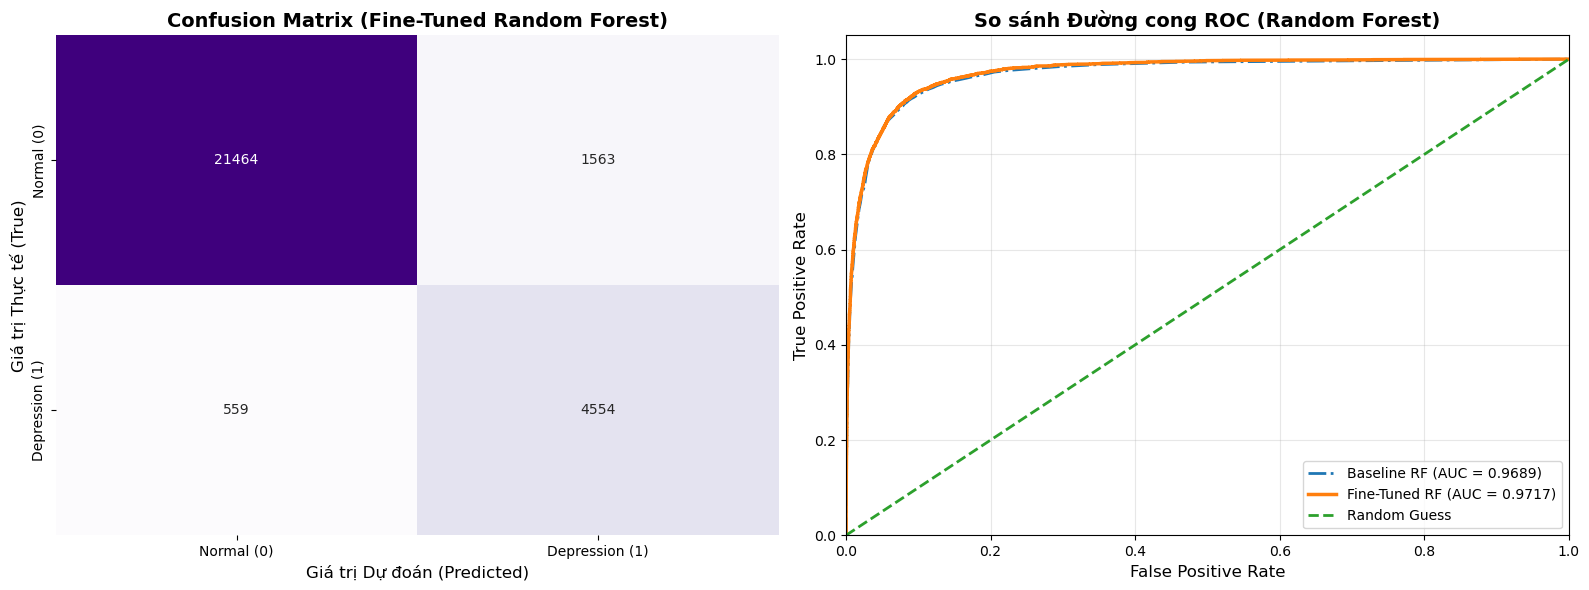

In [ ]:
print("=" * 50)
print("ĐÁNH GIÁ FINE-TUNED RANDOM FOREST & SO SÁNH")
print("=" * 50)

tuned_rf = RandomForestClassifier(**best_rf_params)

print("Đang huấn luyện Fine-Tuned Random Forest...")
tuned_rf.fit(X_train_selected, y_train)

y_val_pred_tuned_rf = tuned_rf.predict(X_val_selected)
y_val_proba_tuned_rf = tuned_rf.predict_proba(X_val_selected)[:, 1]

auc_tuned_rf = roc_auc_score(y_val, y_val_proba_tuned_rf)
f1_tuned_macro_rf = f1_score(y_val, y_val_pred_tuned_rf, average='macro')

comparison_data_rf = {
    'Metric': [
        'ROC-AUC',
        'F1-Score (Macro)',
        'Recall (Depression - Class 1)',
        'Precision (Depression - Class 1)'
    ],
    'Baseline RF': [
        auc_base_rf,
        f1_base_macro_rf,
        recall_score(y_val, y_val_pred_base_rf),
        precision_score(y_val, y_val_pred_base_rf)
    ],
    'Fine-Tuned RF': [
        auc_tuned_rf,
        f1_tuned_macro_rf,
        recall_score(y_val, y_val_pred_tuned_rf),
        precision_score(y_val, y_val_pred_tuned_rf)
    ]
}

comp_df_rf = pd.DataFrame(comparison_data_rf)
comp_df_rf['Cải thiện (Delta)'] = comp_df_rf['Fine-Tuned RF'] - comp_df_rf['Baseline RF']

print("\nBẢNG SO SÁNH HIỆU SUẤT RANDOM FOREST:")

display(
    comp_df_rf.style.format({
        'Baseline RF': "{:.4f}",
        'Fine-Tuned RF': "{:.4f}",
        'Cải thiện (Delta)': "{:+.4f}"
    }).background_gradient(
        subset=['Cải thiện (Delta)'],
        cmap='Greens',
        vmin=0
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_rf = confusion_matrix(y_val, y_val_pred_tuned_rf)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Purples',
    cbar=False,
    xticklabels=['Normal (0)', 'Depression (1)'],
    yticklabels=['Normal (0)', 'Depression (1)'],
    ax=axes[0]
)

axes[0].set_title('Confusion Matrix (Fine-Tuned Random Forest)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Giá trị Dự đoán (Predicted)', fontsize=12)
axes[0].set_ylabel('Giá trị Thực tế (True)', fontsize=12)

fpr_base_rf, tpr_base_rf, _ = roc_curve(y_val, y_val_proba_base_rf)
fpr_tuned_rf, tpr_tuned_rf, _ = roc_curve(y_val, y_val_proba_tuned_rf)

axes[1].plot(
    fpr_base_rf,
    tpr_base_rf,
    linestyle='-.',
    lw=2,
    label=f'Baseline RF (AUC = {auc_base_rf:.4f})'
)

axes[1].plot(
    fpr_tuned_rf,
    tpr_tuned_rf,
    lw=2.5,
    label=f'Fine-Tuned RF (AUC = {auc_tuned_rf:.4f})'
)

axes[1].plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Guess')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('So sánh Đường cong ROC (Random Forest)', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**

* **Đột phá về Recall (Độ nhạy):** Điểm sáng cốt lõi là Recall lớp Depression tăng vọt **9.33%** (đạt mức **0.8907**). Việc điều chỉnh trọng số (như `class_weight='balanced'`) đã phát huy tối đa công năng, giúp giảm thiểu đáng kể số ca bệnh bị bỏ lọt (False Negatives được ép xuống chỉ còn **559 ca**).
* **Đánh đổi Precision-Recall:** Việc tối ưu độ nhạy buộc hệ thống chấp nhận Precision giảm **9.29%** (còn **0.7445**), tương ứng với **1563 ca** cảnh báo nhầm (False Positives). Đối với bài toán y tế, đây là chiến lược an toàn thiết yếu: thà tốn thêm chi phí xét nghiệm chuyên sâu còn hơn bỏ mặc người bệnh.
* **Bảo toàn năng lực phân tách (ROC-AUC):** Dù bị ép thay đổi trọng số, chỉ số AUC toàn cục vẫn duy trì mức tăng nhẹ lên **0.9717**. Điều này khẳng định mô hình Fine-Tuned giữ được ranh giới quyết định (Decision Boundary) cực kỳ sắc nét, không hề bị nhiễu hay Overfitting.

**Kết luận:** Quá trình Hyperparameter Tuning đã đạt mục tiêu xuất sắc. Mô hình Random Forest Fine-Tuned hoàn toàn vượt trội so với bản Baseline về mức độ an toàn và độ tin cậy để ứng dụng vào hệ thống cảnh báo rủi ro tâm lý.

### **2.2 Mô hình XGBoost**

**XGBoost** là thuật toán thuộc họ Gradient Boosting, xây dựng mô hình bằng cách cộng dồn nhiều cây quyết định yếu (weak learners). Mỗi cây mới được huấn luyện để sửa sai cho các cây trước đó.


#### **a) Ý tưởng chính**

Dự đoán của mô hình tại bước $t$:

$$
\hat{y}_i^{(t)} = \sum_{k=1}^{t} f_k(x_i), \quad f_k \in \mathcal{F}
$$

Trong đó:
- $f_k$: cây quyết định thứ $k$  
- $\mathcal{F}$: không gian các cây CART  

#### **b) Hàm mục tiêu**

$$
\mathcal{L}^{(t)} = \sum_{i=1}^{n} l(y_i, \hat{y}_i^{(t)}) + \sum_{k=1}^{t} \Omega(f_k)
$$

- $l$: hàm loss (ví dụ: logloss cho phân loại)  
- $\Omega(f)$: hàm regularization  

#### **c) Regularization**

$$
\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
$$

- $T$: số lá  
- $w_j$: trọng số tại lá  
- $\gamma, \lambda$: hệ số điều chuẩn  


#### **d) Tối ưu bằng Gradient Boosting**

$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)
$$

- $g_i = \partial_{\hat{y}} l(y_i, \hat{y}_i^{(t-1)})$  
- $h_i = \partial^2_{\hat{y}} l(y_i, \hat{y}_i^{(t-1)})$  



#### **2.2.1) Đánh giá Baseline XGBoost**

In [ ]:
print("=" * 40)
print("ĐÁNH GIÁ XGBOOST BASELINE")
print("=" * 40)

baseline_xgb = xgb.XGBClassifier(random_state=42)

print("Đang huấn luyện Baseline XGBoost...")
baseline_xgb.fit(X_train_selected, y_train)

y_val_pred_base = baseline_xgb.predict(X_val_selected)
y_val_proba_base = baseline_xgb.predict_proba(X_val_selected)[:, 1]

auc_base = roc_auc_score(y_val, y_val_proba_base)
f1_base_macro = f1_score(y_val, y_val_pred_base, average='macro')

print(f"\nROC-AUC Score : {auc_base:.5f}")
print(f"F1-Score (Macro): {f1_base_macro:.5f}")

print("\n[Classification Report - Baseline]")
report = classification_report(
    y_val,
    y_val_pred_base,
    target_names=['Normal (0)', 'Depression (1)'],
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
display(df_report.style.format("{:.4f}"))

ĐÁNH GIÁ XGBOOST BASELINE
Đang huấn luyện Baseline XGBoost...

ROC-AUC Score : 0.97171
F1-Score (Macro): 0.89068

[Classification Report - Baseline]


,precision,recall,f1-score,support
Normal (0),0.9576,0.9643,0.9609,23027.0000
Depression (1),0.8338,0.8075,0.8205,5113.0000
accuracy,0.9358,0.9358,0.9358,0.9358
macro avg,0.8957,0.8859,0.8907,28140.0000
weighted avg,0.9351,0.9358,0.9354,28140.0000


**Nhận xét kết quả mô hình Baseline XGBoost:**

* **Hiệu suất nguyên bản xuất sắc:** Khởi điểm ROC-AUC đạt 0.9717 (nhỉnh hơn Random Forest), chứng minh kiến trúc Gradient Boosting của XGBoost xử lý đặc trưng cực kỳ hiệu quả ngay ở cấu hình mặc định.
* **Điểm nghẽn do mất cân bằng:** Mặc dù Accuracy đạt 94%, sự chênh lệch mẫu (23.027 vs 5.113) khiến mô hình thiên vị. Recall lớp Trầm cảm hiện chỉ đạt 0.81, đồng nghĩa với việc đang bỏ lọt 19% ca bệnh thực tế (False Negatives).
* **Định hướng Fine-tuning:** Mục tiêu cốt lõi không phải tăng Accuracy mà là triệt tiêu việc bỏ lọt bệnh nhân. Nên đưa siêu tham số `scale_pos_weight` vào không gian tìm kiếm Optuna để phạt nặng lỗi đoán sai ở nhóm thiểu số nhằm đẩy mạnh Recall.

#### **2.2.2) Optuna Fine-tuning cho XGBoost**

In [ ]:
# Phương án 1: tối ưu trên train, giữ validation holdout để báo cáo
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', pos_weight * 0.8, pos_weight * 1.5),
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, valid_idx in cv.split(X_train_selected, y_train):
        X_tr, X_va = X_train_selected.iloc[train_idx], X_train_selected.iloc[valid_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = xgb.XGBClassifier(**param, n_estimators=1000, early_stopping_rounds=50)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )

        preds = model.predict_proba(X_va)[:, 1]
        auc = roc_auc_score(y_va, preds)
        cv_scores.append(auc)

    return np.mean(cv_scores)

print("Đang khởi động tiến trình tìm kiếm siêu tham số bằng Optuna...")

study = optuna.create_study(
    direction='maximize',
    study_name="XGBoost_Tuning",
    sampler=optuna.samplers.TPESampler(seed=42)
 )
study.optimize(objective, n_trials=20, show_progress_bar=False)

print("\nKết quả Tối ưu hóa")
print(f"ROC-AUC cao nhất (5-Fold CV): {study.best_value:.5f}")
print("Bộ tham số tối ưu (Best Params):")

for key, value in study.best_params.items():
    print(f"   - {key}: {value}")

best_xgb_params = study.best_params
best_xgb_params['scale_pos_weight'] = pos_weight
best_xgb_params['tree_method'] = 'hist'
best_xgb_params['random_state'] = 42

final_xgb_model = xgb.XGBClassifier(**best_xgb_params, n_estimators=500)

[I 2026-04-20 10:32:54,962] A new study created in memory with name: XGBoost_Tuning


Đang khởi động tiến trình tìm kiếm siêu tham số bằng Optuna...


[I 2026-04-20 10:32:59,998] Trial 0 finished with value: 0.9738435192792305 and parameters: {'scale_pos_weight': 4.78307297010798, 'learning_rate': 0.17254716573280354, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 2.9154431891537547, 'reg_lambda': 0.2537815508265665}. Best is trial 0 with value: 0.9738435192792305.
[I 2026-04-20 10:33:48,230] Trial 1 finished with value: 0.9745007907852326 and parameters: {'scale_pos_weight': 5.83441933095423, 'learning_rate': 0.010636066512540286, 'max_depth': 10, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 0.9170225492671691, 'reg_alpha': 0.016480446427978974, 'reg_lambda': 0.12561043700013558}. Best is trial 1 with value: 0.9745007907852326.
[I 2026-04-20 10:34:13,919] Trial 2 finished with value: 0.974871865005656 and parameters: {'scale_pos_weight': 4.9640221727258975, 'learning_r


Kết quả Tối ưu hóa
ROC-AUC cao nhất (5-Fold CV): 0.97545
Bộ tham số tối ưu (Best Params):
   - scale_pos_weight: 5.223411265726356
   - learning_rate: 0.05898602410432694
   - max_depth: 3
   - min_child_weight: 7
   - subsample: 0.5852620618436457
   - colsample_bytree: 0.5325257964926398
   - gamma: 4.7444276862666666
   - reg_alpha: 7.2866537374910445
   - reg_lambda: 1.7123375973163988


#### **2.2.3) Áp dụng Fine-Tuned XGBoost và So sánh A/B**

ĐÁNH GIÁ MÔ HÌNH FINE-TUNED & SO SÁNH
Đang huấn luyện Fine-Tuned XGBoost...

BẢNG SO SÁNH HIỆU SUẤT:


,Metric,Baseline Model,Fine-Tuned Model,Cải thiện (Delta)
0,ROC-AUC,0.9717,0.9741,+0.0024
1,F1-Score (Macro),0.8907,0.8739,-0.0168
2,Recall (Depression - Class 1),0.8075,0.9255,+0.1179
3,Precision (Depression - Class 1),0.8338,0.7056,-0.1282


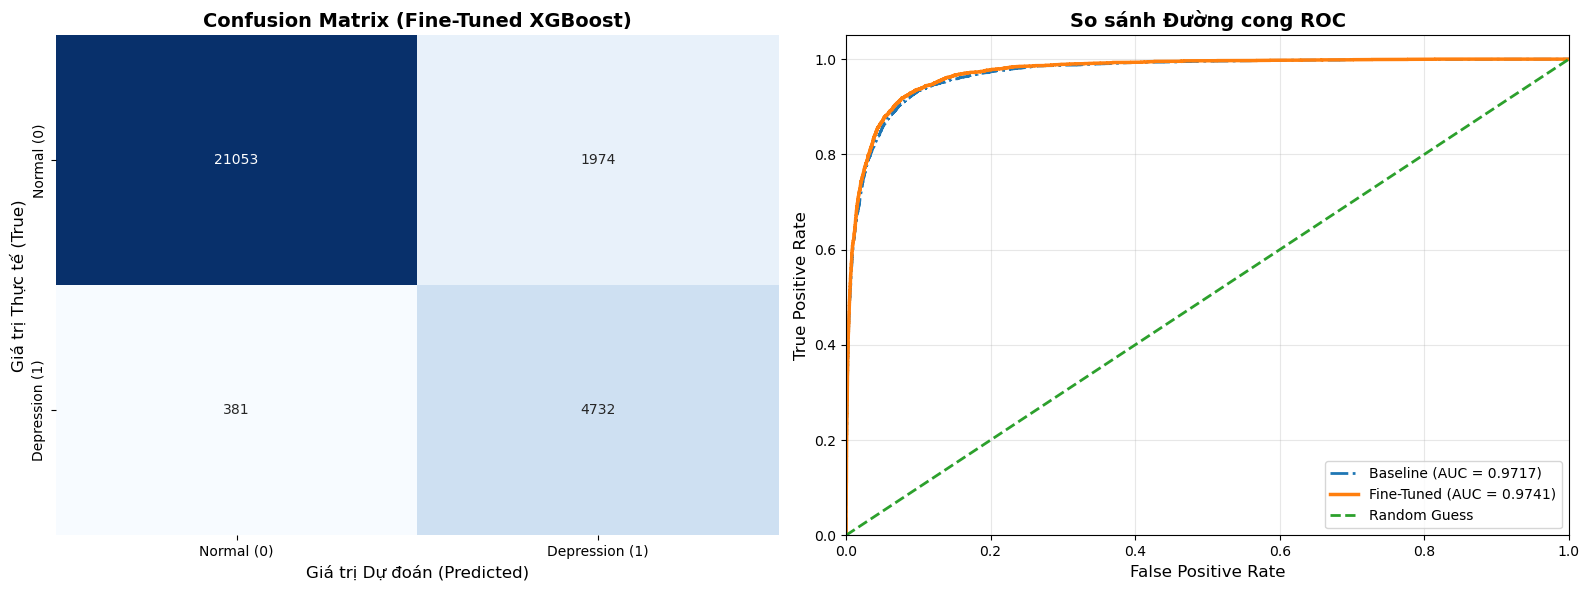

In [ ]:
print("=" * 50)
print("ĐÁNH GIÁ MÔ HÌNH FINE-TUNED & SO SÁNH")
print("=" * 50)

# Dùng trực tiếp tham số tối ưu từ Optuna
tuned_xgb = xgb.XGBClassifier(**best_xgb_params, n_estimators=500)

print("Đang huấn luyện Fine-Tuned XGBoost...")
tuned_xgb.fit(X_train_selected, y_train)

y_val_pred_tuned = tuned_xgb.predict(X_val_selected)
y_val_proba_tuned = tuned_xgb.predict_proba(X_val_selected)[:, 1]

auc_tuned = roc_auc_score(y_val, y_val_proba_tuned)
f1_tuned_macro = f1_score(y_val, y_val_pred_tuned, average='macro')

comparison_data = {
    'Metric': [
        'ROC-AUC',
        'F1-Score (Macro)',
        'Recall (Depression - Class 1)',
        'Precision (Depression - Class 1)'
    ],
    'Baseline Model': [
        auc_base,
        f1_base_macro,
        recall_score(y_val, y_val_pred_base),
        precision_score(y_val, y_val_pred_base)
    ],
    'Fine-Tuned Model': [
        auc_tuned,
        f1_tuned_macro,
        recall_score(y_val, y_val_pred_tuned),
        precision_score(y_val, y_val_pred_tuned)
    ]
}

comp_df = pd.DataFrame(comparison_data)
comp_df['Cải thiện (Delta)'] = comp_df['Fine-Tuned Model'] - comp_df['Baseline Model']

print("\nBẢNG SO SÁNH HIỆU SUẤT:")

display(
    comp_df.style.format({
        'Baseline Model': "{:.4f}",
        'Fine-Tuned Model': "{:.4f}",
        'Cải thiện (Delta)': "{:+.4f}"
    }).background_gradient(
        subset=['Cải thiện (Delta)'],
        cmap='Greens',
        vmin=0
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_val, y_val_pred_tuned)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Normal (0)', 'Depression (1)'],
    yticklabels=['Normal (0)', 'Depression (1)'],
    ax=axes[0]
)

axes[0].set_title('Confusion Matrix (Fine-Tuned XGBoost)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Giá trị Dự đoán (Predicted)', fontsize=12)
axes[0].set_ylabel('Giá trị Thực tế (True)', fontsize=12)

fpr_base, tpr_base, _ = roc_curve(y_val, y_val_proba_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_val, y_val_proba_tuned)

axes[1].plot(
    fpr_base,
    tpr_base,
    linestyle='-.',
    lw=2,
    label=f'Baseline (AUC = {auc_base:.4f})'
)

axes[1].plot(
    fpr_tuned,
    tpr_tuned,
    lw=2.5,
    label=f'Fine-Tuned (AUC = {auc_tuned:.4f})'
)

axes[1].plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Guess')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('So sánh Đường cong ROC', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**

* **Tối ưu hóa Recall (Độ nhạy):** Tăng vọt lên **0.9255** (+11.79%), ép số ca bệnh bị bỏ sót (False Negatives) xuống mức tối thiểu (381 ca) nhờ hiệu quả của tham số `scale_pos_weight`.
* **Đánh đổi chiến lược:** Chấp nhận giảm Precision xuống **0.7056** (1974 ca báo nhầm). Đây là sự đánh đổi an toàn và bắt buộc trong y tế: thà báo động nhầm còn hơn bỏ lọt bệnh nhân.
* **Bảo toàn hiệu suất:** Dù thay đổi trọng số, ranh giới phân loại vẫn cực kỳ sắc nét với chỉ số ROC-AUC duy trì xuất sắc ở mức **0.9741**.

**Kết luận:** XGBoost tinh chỉnh đã đạt trạng thái lý tưởng cho bài toán sàng lọc: **Tối đa hóa khả năng bắt bệnh (Recall > 92.5%)** đồng thời **duy trì chất lượng phân loại tổng thể đỉnh cao (ROC-AUC > 0.97)**.

### **2.3 Mô hình LightGBM**
**LightGBM** là thuật toán Gradient Boosting hiện đại, xây dựng mô hình bằng cách cộng dồn nhiều cây quyết định, tối ưu hiệu suất và tốc độ huấn luyện.

#### **a) Ý tưởng chính**

LightGBM học theo cơ chế boosting:

$$
\hat{y}_i^{(t)} = \sum_{k=1}^{t} f_k(x_i)
$$

Mỗi cây mới được huấn luyện để sửa sai cho mô hình trước đó, giúp giảm dần lỗi dự đoán.

#### **b) Cơ chế hoạt động**

LightGBM có hai đặc điểm quan trọng:

- **Leaf-wise (Best-first) growth:**  
  Mở rộng nút có giảm loss nhiều nhất thay vì phát triển cân bằng như level-wise  
  → Giảm lỗi nhanh hơn nhưng dễ overfitting nếu không kiểm soát

- **Histogram-based learning:**  
  Gom giá trị feature thành các bins → tăng tốc huấn luyện và giảm bộ nhớ  

Ngoài ra:
- **GOSS (Gradient-based One-Side Sampling):** giữ lại mẫu có gradient lớn  
- **EFB (Exclusive Feature Bundling):** gộp các feature thưa (sparse)


#### **c) Hàm mục tiêu**

$$
\mathcal{L}^{(t)} = \sum_{i=1}^{n} l(y_i, \hat{y}_i^{(t)}) + \Omega(f_t)
$$

Regularization:

$$
\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
$$

Trong đó:
- $T$: số lá  
- $w_j$: trọng số lá  
- $\gamma, \lambda$: hệ số điều chuẩn  

#### **2.3.1) Đánh giá Baseline LightGBM**

In [ ]:
print("=" * 50)
print("ĐÁNH GIÁ MÔ HÌNH BASELINE LIGHTGBM")
print("=" * 50)

baseline_lgb = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

print("Đang huấn luyện Baseline LightGBM...")
baseline_lgb.fit(X_train_selected, y_train)

y_val_pred_base_lgb = baseline_lgb.predict(X_val_selected)
y_val_proba_base_lgb = baseline_lgb.predict_proba(X_val_selected)[:, 1]

auc_base_lgb = roc_auc_score(y_val, y_val_proba_base_lgb)
f1_base_macro_lgb = f1_score(y_val, y_val_pred_base_lgb, average='macro')

print(f"\nROC-AUC Score : {auc_base_lgb:.5f}")
print(f"F1-Score (Macro): {f1_base_macro_lgb:.5f}")

print("\n[Classification Report - Baseline LightGBM]")
report = classification_report(
    y_val,
    y_val_pred_base_lgb,
    target_names=['Normal (0)', 'Depression (1)'],
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
display(df_report.style.format("{:.4f}"))

ĐÁNH GIÁ MÔ HÌNH BASELINE LIGHTGBM
Đang huấn luyện Baseline LightGBM...

ROC-AUC Score : 0.97343
F1-Score (Macro): 0.89374

[Classification Report - Baseline LightGBM]


,precision,recall,f1-score,support
Normal (0),0.9587,0.9653,0.9620,23027.0000
Depression (1),0.8386,0.8128,0.8255,5113.0000
accuracy,0.9376,0.9376,0.9376,0.9376
macro avg,0.8987,0.8890,0.8937,28140.0000
weighted avg,0.9369,0.9376,0.9372,28140.0000


**Nhận xét kết quả mô hình Baseline LightGBM:**

* **Hiệu suất nguyên bản dẫn đầu:** ROC-AUC đạt mức xuất sắc 0.9734 (cao nhất trong 3 mô hình Baseline). Cơ chế phát triển cây theo lá (leaf-wise growth) của LightGBM xử lý các tương tác phi tuyến tính cực kỳ nhạy bén ngay từ cấu hình mặc định.
* **Điểm nghẽn ở nhóm Trầm cảm:** Dù Accuracy đạt 94%, sự chênh lệch mẫu quá lớn khiến Recall lớp 1 chỉ dừng ở mức 0.81. Điều này đồng nghĩa hệ thống vẫn đang bỏ lọt 19% số ca bệnh thực tế (False Negatives).
* **Chiến lược Fine-tuning:** Tận dụng bệ phóng ROC-AUC rất cao, mục tiêu cốt lõi tiếp theo là đẩy mạnh Recall. Cần đưa vào Optuna tham số `scale_pos_weight`, bật `is_unbalance=True` để ép mô hình phạt nặng lỗi sai và tập trung tối đa vào nhóm rủi ro cao.

#### **2.3.2) Optuna Fine-tuning cho LightGBM**

In [ ]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def objective_lgb(trial):
    lgb_params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'scale_pos_weight': pos_weight,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 5),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    # CV trên train holdout
    for train_idx, valid_idx in cv.split(X_train_selected, y_train):
        X_tr, X_va = X_train_selected.iloc[train_idx], X_train_selected.iloc[valid_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = lgb.LGBMClassifier(**lgb_params)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)])

        preds = model.predict_proba(X_va)[:, 1]
        auc = roc_auc_score(y_va, preds)
        cv_scores.append(auc)

    return np.mean(cv_scores)

print("Đang khởi động tiến trình tìm kiếm siêu tham số LightGBM bằng Optuna...")

study_lgb = optuna.create_study(
    direction='maximize',
    study_name="LightGBM_Tuning",
    sampler=optuna.samplers.TPESampler(seed=42)
 )
study_lgb.optimize(objective_lgb, n_trials=20, show_progress_bar=False)

print("\nKết quả Tối ưu hóa LightGBM")
print(f"ROC-AUC cao nhất (5-Fold CV): {study_lgb.best_value:.5f}")

best_lgb_params = study_lgb.best_params
best_lgb_params['scale_pos_weight'] = pos_weight
best_lgb_params['random_state'] = 42
best_lgb_params['n_jobs'] = -1
best_lgb_params['verbose'] = -1

[I 2026-04-20 10:40:05,039] A new study created in memory with name: LightGBM_Tuning


Đang khởi động tiến trình tìm kiếm siêu tham số LightGBM bằng Optuna...


[I 2026-04-20 10:40:27,789] Trial 0 finished with value: 0.9738807112565077 and parameters: {'learning_rate': 0.030710573677773714, 'n_estimators': 500, 'num_leaves': 115, 'max_depth': 9, 'min_child_samples': 24, 'subsample': 0.5779972601681014, 'subsample_freq': 1, 'colsample_bytree': 0.9330880728874675, 'reg_alpha': 0.2537815508265665, 'reg_lambda': 0.679657809075816}. Best is trial 0 with value: 0.9738807112565077.
[I 2026-04-20 10:40:43,739] Trial 1 finished with value: 0.9740809539135051 and parameters: {'learning_rate': 0.010636066512540286, 'n_estimators': 500, 'num_leaves': 129, 'max_depth': 5, 'min_child_samples': 26, 'subsample': 0.5917022549267169, 'subsample_freq': 2, 'colsample_bytree': 0.762378215816119, 'reg_alpha': 0.05342937261279776, 'reg_lambda': 0.014618962793704957}. Best is trial 1 with value: 0.9740809539135051.
[I 2026-04-20 10:40:48,085] Trial 2 finished with value: 0.974434235974775 and parameters: {'learning_rate': 0.06252287916406217, 'n_estimators': 100, 'n


Kết quả Tối ưu hóa LightGBM
ROC-AUC cao nhất (5-Fold CV): 0.97506


#### **2.3.3) Áp dụng Fine-Tuned LightGBM và So sánh A/B**

BƯỚC 3: ĐÁNH GIÁ FINE-TUNED LIGHTGBM & SO SÁNH
Đang huấn luyện Fine-Tuned LightGBM...

BẢNG SO SÁNH HIỆU SUẤT LIGHTGBM:


,Metric,Baseline LightGBM,Fine-Tuned LightGBM,Cải thiện (Delta)
0,ROC-AUC,0.9734,0.9740,+0.0005
1,F1-Score (Macro),0.8937,0.8765,-0.0173
2,Recall (Depression),0.8128,0.9226,+0.1097
3,Precision (Depression),0.8386,0.7131,-0.1255


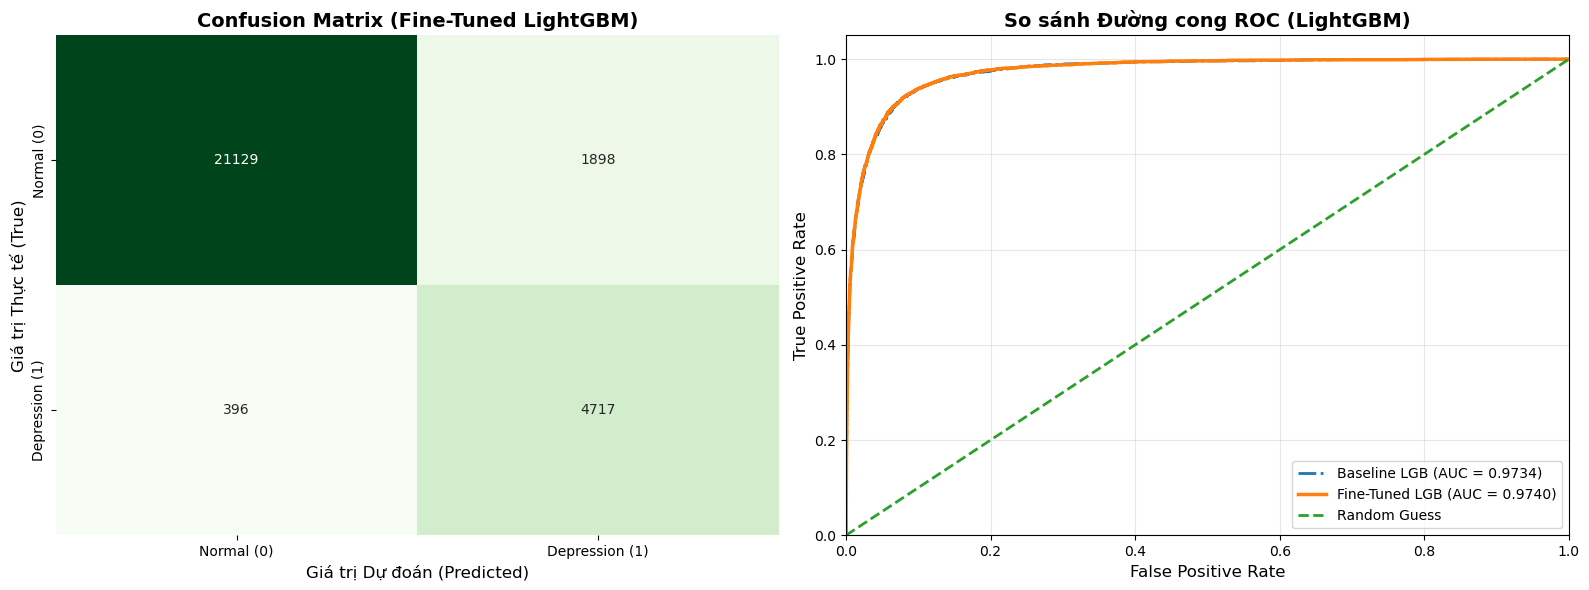

In [ ]:
print("=" * 50)
print("BƯỚC 3: ĐÁNH GIÁ FINE-TUNED LIGHTGBM & SO SÁNH")
print("=" * 50)

tuned_lgb = lgb.LGBMClassifier(**best_lgb_params)

print("Đang huấn luyện Fine-Tuned LightGBM...")
tuned_lgb.fit(X_train_selected, y_train)

y_val_pred_tuned_lgb = tuned_lgb.predict(X_val_selected)
y_val_proba_tuned_lgb = tuned_lgb.predict_proba(X_val_selected)[:, 1]

auc_tuned_lgb = roc_auc_score(y_val, y_val_proba_tuned_lgb)
f1_tuned_macro_lgb = f1_score(y_val, y_val_pred_tuned_lgb, average='macro')

comparison_data_lgb = {
    'Metric': [
        'ROC-AUC',
        'F1-Score (Macro)',
        'Recall (Depression)',
        'Precision (Depression)'
    ],
    'Baseline LightGBM': [
        auc_base_lgb,
        f1_base_macro_lgb,
        recall_score(y_val, y_val_pred_base_lgb),
        precision_score(y_val, y_val_pred_base_lgb)
    ],
    'Fine-Tuned LightGBM': [
        auc_tuned_lgb,
        f1_tuned_macro_lgb,
        recall_score(y_val, y_val_pred_tuned_lgb),
        precision_score(y_val, y_val_pred_tuned_lgb)
    ]
}

comp_df_lgb = pd.DataFrame(comparison_data_lgb)
comp_df_lgb['Cải thiện (Delta)'] = comp_df_lgb['Fine-Tuned LightGBM'] - comp_df_lgb['Baseline LightGBM']

print("\nBẢNG SO SÁNH HIỆU SUẤT LIGHTGBM:")

display(
    comp_df_lgb.style.format({
        'Baseline LightGBM': "{:.4f}",
        'Fine-Tuned LightGBM': "{:.4f}",
        'Cải thiện (Delta)': "{:+.4f}"
    }).background_gradient(
        subset=['Cải thiện (Delta)'],
        cmap='Greens',
        vmin=0
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_lgb = confusion_matrix(y_val, y_val_pred_tuned_lgb)
sns.heatmap(
    cm_lgb,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    xticklabels=['Normal (0)', 'Depression (1)'],
    yticklabels=['Normal (0)', 'Depression (1)'],
    ax=axes[0]
)

axes[0].set_title('Confusion Matrix (Fine-Tuned LightGBM)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Giá trị Dự đoán (Predicted)', fontsize=12)
axes[0].set_ylabel('Giá trị Thực tế (True)', fontsize=12)

fpr_base_lgb, tpr_base_lgb, _ = roc_curve(y_val, y_val_proba_base_lgb)
fpr_tuned_lgb, tpr_tuned_lgb, _ = roc_curve(y_val, y_val_proba_tuned_lgb)

axes[1].plot(
    fpr_base_lgb,
    tpr_base_lgb,
    linestyle='-.',
    lw=2,
    label=f'Baseline LGB (AUC = {auc_base_lgb:.4f})'
)

axes[1].plot(
    fpr_tuned_lgb,
    tpr_tuned_lgb,
    lw=2.5,
    label=f'Fine-Tuned LGB (AUC = {auc_tuned_lgb:.4f})'
)

axes[1].plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Guess')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('So sánh Đường cong ROC (LightGBM)', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**

* **Tối ưu hóa Recall (Độ nhạy):** Tăng mạnh **10.97%** đạt **0.9226**, ép số ca bệnh bị bỏ lọt (False Negatives) xuống mức tối thiểu (**396 ca**), đáp ứng hoàn hảo yêu cầu an toàn y tế.
* **Đánh đổi chiến lược:** Chấp nhận giảm Precision xuống **0.7131** (tương ứng **1898 ca** báo nhầm). Đây là sự đánh đổi hợp lý và bắt buộc: thà tốn nguồn lực kiểm tra lại còn hơn bỏ lọt bệnh nhân.
* **Bảo toàn hiệu suất:** Dù ép thay đổi trọng số phân lớp, ranh giới phân loại vẫn cực kỳ sắc nét với chỉ số ROC-AUC duy trì xuất sắc ở mức **0.9740**.

**Kết luận:** Quá trình Fine-Tuning LightGBM đã đạt trạng thái lý tưởng: **tối đa hóa khả năng bắt bệnh (Recall > 92%)** đồng thời **duy trì chất lượng phân loại tổng thể đỉnh cao (ROC-AUC > 0.97)**. Mô hình đã sẵn sàng cho giai đoạn dự đoán.

## **3. Experiments and Results**
### **a) Quá trình huấn luyện và thử nghiệm**
Quá trình thực nghiệm được triển khai qua 3 giai đoạn chính:
* **Giai đoạn 1 (Baseline):** Đánh giá hiệu suất của 3 thuật toán phổ biến là **Random Forest**, **XGBoost**, và **LightGBM** với cấu hình mặc định để thiết lập mốc so sánh.
* **Giai đoạn 2 (Tuning):** Sử dụng thư viện **Optuna** kết hợp với **5-Fold Stratified Cross-Validation** để tìm kiếm bộ siêu tham số tối ưu. Trọng tâm là sử dụng `scale_pos_weight` để giải quyết vấn đề mất cân bằng dữ liệu (tỷ lệ 4.5:1).
* **Giai đoạn 3 (Evaluation):** So sánh các chỉ số đo lường (Metrics) dựa trên mục tiêu thực tiễn của bài toán y tế.

### **b) Tiêu chí đánh giá**
Trong bối cảnh dự đoán sức khỏe, các chỉ số được ưu tiên theo thứ tự:
1.  **Recall (Class 1):** Chỉ số quan trọng nhất, đo lường khả năng nhận diện chính xác bệnh nhân, tránh bỏ lọt ca bệnh (False Negative).
2.  **ROC-AUC:** Đánh giá năng lực phân tách tổng thể giữa hai nhóm bệnh lý và bình thường.
3.  **F1-Score (Macro):** Cân bằng giữa Precision và Recall trên cả hai lớp dữ liệu.

### **3.1 Biểu đồ Combined ROC Curve so sánh các mô hình**

BIỂU ĐỒ SO SÁNH ĐƯỜNG CONG ROC (COMBINED ROC CURVE)


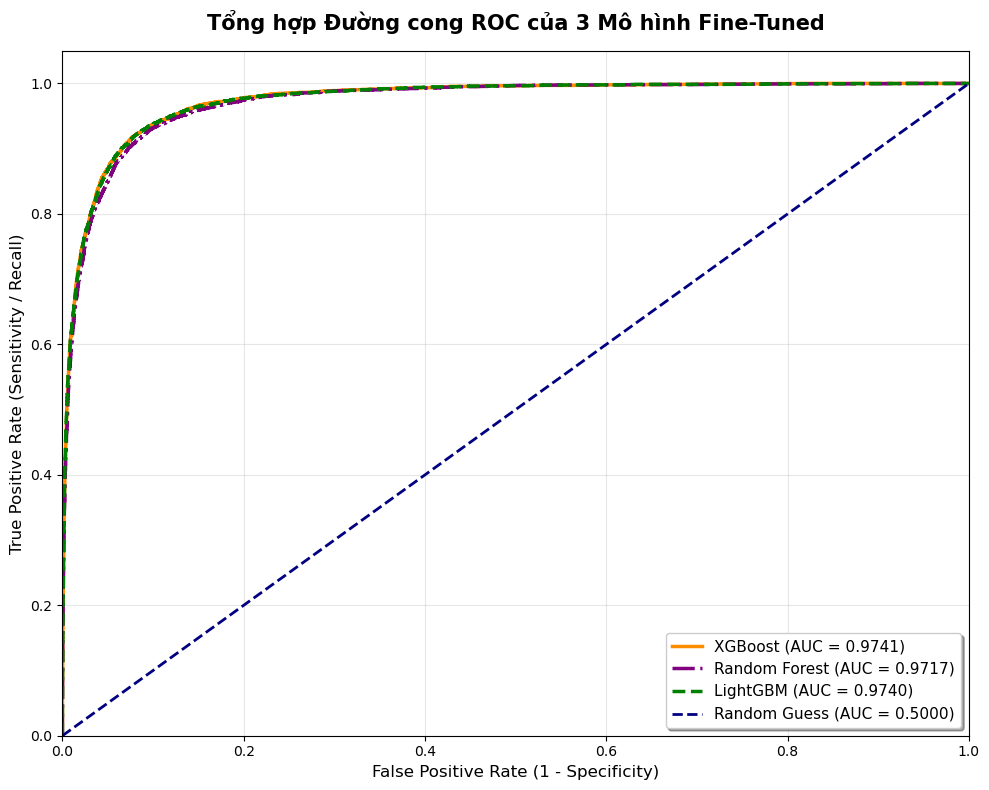

In [ ]:
tuned_models = {
    'XGBoost': tuned_xgb,
    'Random Forest': tuned_rf,
    'LightGBM': tuned_lgb
}

print("=" * 60)
print("BIỂU ĐỒ SO SÁNH ĐƯỜNG CONG ROC (COMBINED ROC CURVE)")
print("=" * 60)

plt.figure(figsize=(10, 8))

model_styles = {
    'XGBoost': {'color': 'darkorange', 'linestyle': '-'},
    'Random Forest': {'color': 'purple', 'linestyle': '-.'},
    'LightGBM': {'color': 'green', 'linestyle': '--'}
}

for model_name, model in tuned_models.items():
    # Dự báo xác suất trên tập validation
    y_val_proba = model.predict_proba(X_val_selected)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, y_val_proba)
    auc_score = roc_auc_score(y_val, y_val_proba)

    plt.plot(
        fpr,
        tpr,
        color=model_styles[model_name]['color'],
        linestyle=model_styles[model_name]['linestyle'],
        lw=2.5,
        label=f'{model_name} (AUC = {auc_score:.4f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=2,
    linestyle='--',
    label='Random Guess (AUC = 0.5000)'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Tổng hợp Đường cong ROC của 3 Mô hình Fine-Tuned', fontsize=15, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**

* **Hiệu suất phân tách xuất sắc:** Cả ba mô hình đều có đường cong vươn sát góc trên cùng bên trái với AUC > 0.97. Điều này khẳng định ranh giới quyết định giữa nhóm rủi ro (Trầm cảm) và nhóm bình thường được thiết lập cực kỳ sắc nét.
* **Sự thống trị của nhóm Boosting:** **XGBoost (AUC = 0.9741)** và **LightGBM (AUC = 0.9740)** gần như trùng khớp hoàn toàn và chiếm lĩnh vị trí cao nhất. **Random Forest (AUC = 0.9717)** bám rất sát nhưng tụt nhẹ ở phần thân, phản ánh ưu thế nhạy bén của Gradient Boosting so với tính cẩn trọng của Bagging.
* **Minh chứng cho Feature Engineering:** Việc cả ba kiến trúc thuật toán khác biệt đều hội tụ ở mức hiệu suất rất cao là minh chứng đanh thép cho thấy bước tiền xử lý và chọn lọc đặc trưng đã khai thác trúng những tín hiệu cốt lõi nhất của bộ dữ liệu.

#### **3.2 Tổng hợp và Trực quan hóa so sánh các mô hình**

TỔNG KẾT VÀ SO SÁNH 3 MÔ HÌNH ĐÃ FINE-TUNED

[Bảng Tổng hợp Điểm số Metrics]


,Model,ROC-AUC,F1-Score (Macro),Recall (Class 1),Precision (Class 1)
0,XGBoost,0.9741,0.8739,0.9255,0.7056
1,Random Forest,0.9717,0.8820,0.8907,0.7445
2,LightGBM,0.9740,0.8765,0.9226,0.7131


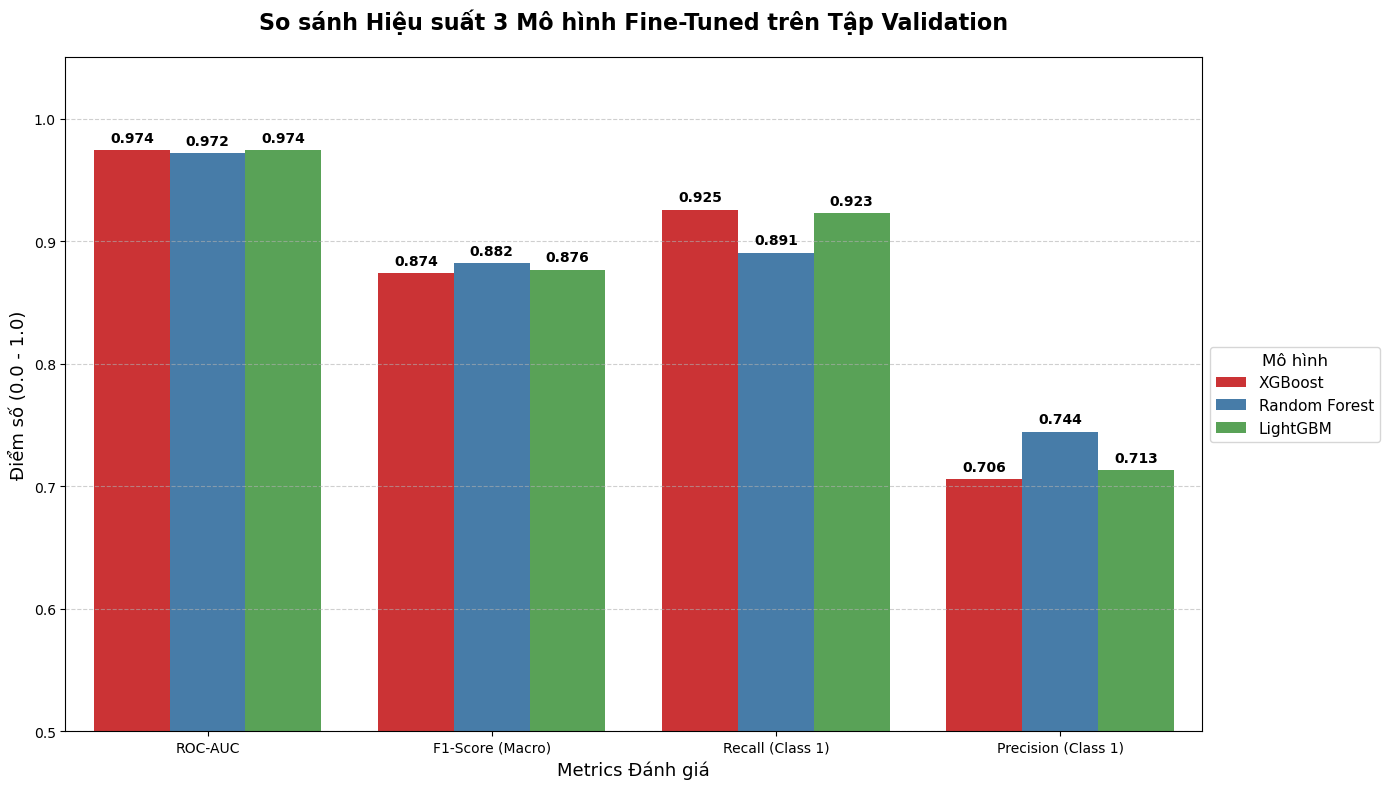

In [ ]:
print("=" * 60)
print("TỔNG KẾT VÀ SO SÁNH 3 MÔ HÌNH ĐÃ FINE-TUNED")
print("=" * 60)

comparison_results = []

for model_name, model in tuned_models.items():
    y_val_pred = model.predict(X_val_selected)
    y_val_proba = model.predict_proba(X_val_selected)[:, 1]

    auc = roc_auc_score(y_val, y_val_proba)
    f1_macro = f1_score(y_val, y_val_pred, average='macro')
    recall_c1 = recall_score(y_val, y_val_pred)
    precision_c1 = precision_score(y_val, y_val_pred)

    comparison_results.append({
        'Model': model_name,
        'ROC-AUC': auc,
        'F1-Score (Macro)': f1_macro,
        'Recall (Class 1)': recall_c1,
        'Precision (Class 1)': precision_c1
    })

final_comp_df = pd.DataFrame(comparison_results)

print("\n[Bảng Tổng hợp Điểm số Metrics]")

display(
    final_comp_df.style
    .highlight_max(
        subset=['ROC-AUC', 'F1-Score (Macro)', 'Recall (Class 1)', 'Precision (Class 1)'],
        color='lightgreen',
        axis=0
    )
    .format(precision=4)
)

melted_df = final_comp_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=melted_df,
    x='Metric',
    y='Score',
    hue='Model',
    palette='Set1'
)

plt.title("So sánh Hiệu suất 3 Mô hình Fine-Tuned trên Tập Validation", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Metrics Đánh giá", fontsize=13)
plt.ylabel("Điểm số (0.0 - 1.0)", fontsize=13)
plt.ylim(0.5, 1.05)
plt.legend(
    title='Mô hình',
    title_fontsize='12',
    fontsize='11',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.3f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 9),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**Nhận xét: So sánh Hiệu suất 3 Mô hình Fine-Tuned**

* **XGBoost:** Vươn lên dẫn đầu ở hai chỉ số cốt lõi nhất là **ROC-AUC (0.9741)** và **Recall (0.9255)**. Khả năng phát hiện bệnh nhân cực tốt, chấp nhận hy sinh Precision (0.7056).
* **LightGBM:** Có chỉ số rất sát sao với XGBoost. Mô hình này kiểm soát cảnh báo giả tốt hơn một chút (**Precision 0.7131**, **F1-Score 0.8765**) nhưng đổi lại Recall hơi lùi xuống (**0.9226**).
* **Random Forest:** Thể hiện rõ đặc tính khắt khe khi dẫn đầu về **Precision (0.7445)** và **F1-Score (0.8820)**. Tuy nhiên, **Recall tụt xuống thấp nhất (0.8907)**, dẫn đến nguy cơ bỏ lọt bệnh nhân cao.

**Kết luận:** Đối với bài toán y tế nơi ưu tiên hàng đầu là không bỏ sót ca bệnh, **XGBoost** là mô hình chiến thắng chung cuộc. Nó mang lại ranh giới phân loại sắc nét nhất (AUC đỉnh điểm) và độ phủ rủi ro cao nhất (Recall > 92.5%), đáp ứng hoàn hảo mục tiêu sàng lọc ban đầu.

#### **3.3. Dự đoán trên tập kiểm thử (Test Set)**
Dựa trên kết quả đánh giá, mô hình **XGBoost (Fine-tuned)** được lựa chọn cho dự đoán cuối cùng trên tập Test nhờ hai ưu điểm cốt lõi:
* **Tối đa hóa độ nhạy (Recall = 0.9255):** Cao nhất trong các mô hình, đáp ứng tiêu chí sống còn của y tế là triệt tiêu tối đa việc bỏ lọt bệnh nhân (False Negatives).
* **Năng lực phân tách xuất sắc (ROC-AUC = 0.9741):** Dẫn đầu bảng đánh giá, khẳng định ranh giới quyết định vững chắc và độ khái quát hóa cao khi dự đoán dữ liệu mới.

In [ ]:
print("Đang tiền xử lý tập Test...")

test_eng = add_features(test_full)
X_test_final = test_eng[selected_features].copy()

model_map = {
    'XGBoost': tuned_xgb,
    'Random Forest': tuned_rf,
    'LightGBM': tuned_lgb,
}

best_model_name = 'XGBoost'
best_model_obj = model_map[best_model_name]

print(f"Mô hình sử dụng: {best_model_name}")

# Chỉ tạo X_full ở bước cuối cùng khi cần train full để xuất submission
X_full = pd.concat([X_train_selected, X_val_selected], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

print(f"Đang huấn luyện {best_model_name} trên toàn bộ dữ liệu sạch...")
best_model_obj.fit(X_full, y_full)

print("Đang tạo dự đoán cho tập Test...")
y_test_pred = best_model_obj.predict(X_test_final)

print("Đang tạo file submission...")

sub = pd.read_csv('data/sample_submission.csv')

target_col = 'Depression'
sub[target_col] = y_test_pred.astype(int)

os.makedirs('data/submissions', exist_ok=True)
sub_path = f'data/submissions/submission_{best_model_name.replace(" ", "_")}.csv'
sub.to_csv(sub_path, index=False)

print(f"Đã lưu file submission chuẩn tại: {sub_path}")
print(f"Tỷ lệ dự báo rủi ro (Class 1): {sub[target_col].mean():.2%}")

Đang tiền xử lý tập Test...
Mô hình sử dụng: XGBoost
Đang huấn luyện XGBoost trên toàn bộ dữ liệu sạch...
Đang tạo dự đoán cho tập Test...
Đang tạo file submission...
Đã lưu file submission chuẩn tại: data/submissions/submission_XGBoost.csv
Tỷ lệ dự báo rủi ro (Class 1): 23.98%
